# 03 — Modélisation & MLflow
## Projet : Home Credit Default Risk — MLOps Pipeline

**Ce qu'on fait dans ce notebook :**
1. Définir le Score Métier
2. Séparer les données (train / test)
3. Entraîner 3 modèles
4. Comparer avec MLflow
5. Analyser les features importantes avec SHAP

---

## 0. Imports et chargement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    classification_report, roc_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# SHAP
import shap

# Sauvegarde modèle
import joblib

os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

COLOR_POS = '#E07B4F'
COLOR_NEG = '#2C5F8A'

print('✅ Imports OK')
print(f'   MLflow version : {mlflow.__version__}')

✅ Imports OK
   MLflow version : 3.14.0


In [2]:
# Chargement du dataset nettoyé (produit par le notebook 02)
df = pd.read_csv('../data/processed/application_train_clean.csv')

print(f'✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   TARGET : {df["TARGET"].value_counts().to_dict()}')

✅ Dataset chargé : 307,511 lignes × 219 colonnes
   TARGET : {0: 282686, 1: 24825}


---
## Étape 1 — Définir le Score Métier

**Pourquoi ne pas utiliser l'accuracy ?**

Notre dataset a 91,9% de classe 0 et 8,1% de classe 1.  
Un modèle qui prédit TOUJOURS 0 (jamais de défaut) aurait 91,9% d'accuracy.  
C'est excellent en apparence, mais complètement inutile en pratique.

**Les deux types d'erreurs et leurs coûts :**

| Erreur | Description | Coût |
|---|---|---|
| Faux Négatif (FN) | On prédit "remboursé" mais le client fait défaut | 💸 Très élevé — la banque perd l'argent prêté |
| Faux Positif (FP) | On prédit "défaut" mais le client aurait remboursé | 😕 Modéré — on refuse un bon client |

**Conclusion :** Un Faux Négatif coûte beaucoup plus cher qu'un Faux Positif.  
Notre score métier doit pénaliser davantage les Faux Négatifs.

In [3]:
def score_metier(y_true, y_pred, cout_fn=5, cout_fp=1):
    """
    Score Métier personnalisé pour le risque de crédit.
    
    Paramètres :
    - y_true   : vraies valeurs (0 ou 1)
    - y_pred   : prédictions du modèle (0 ou 1)
    - cout_fn  : coût d'un Faux Négatif (défaut non détecté) → par défaut 5
    - cout_fp  : coût d'un Faux Positif (bon client refusé) → par défaut 1
    
    Retourne :
    - Un score entre 0 et 1 (plus c'est élevé, mieux c'est)
    
    Logique :
    - On calcule le coût total des erreurs
    - On le compare au coût maximum possible (si on se trompait sur tout)
    - Score = 1 - (coût réel / coût maximum)
    """
    cm = confusion_matrix(y_true, y_pred)
    
    # Extraire FP et FN de la matrice de confusion
    # cm = [[TN, FP],
    #        [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    
    # Coût total des erreurs
    cout_total = (cout_fn * fn) + (cout_fp * fp)
    
    # Coût maximum = si on se trompait sur tous les positifs et négatifs
    cout_max = (cout_fn * (fn + tp)) + (cout_fp * (fp + tn))
    
    # Score entre 0 et 1
    score = 1 - (cout_total / cout_max)
    
    return score


# Test rapide pour vérifier que la fonction marche
y_test_exemple  = np.array([0, 0, 1, 1, 0, 1])
y_pred_exemple  = np.array([0, 1, 0, 1, 0, 1])  # 1 FP et 1 FN
y_pred_parfait  = np.array([0, 0, 1, 1, 0, 1])  # aucune erreur
y_pred_nul      = np.array([0, 0, 0, 0, 0, 0])  # prédit toujours 0

print('Test du Score Métier :')
print(f'  Prédiction parfaite : {score_metier(y_test_exemple, y_pred_parfait):.4f} → doit être proche de 1')
print(f'  Prédiction avec erreurs : {score_metier(y_test_exemple, y_pred_exemple):.4f}')
print(f'  Prédit toujours 0 : {score_metier(y_test_exemple, y_pred_nul):.4f} → pénalise les FN')
print()
print('✅ Score Métier défini')
print('   cout_fn = 5 → rater un défaut coûte 5x plus cher que refuser un bon client')

Test du Score Métier :
  Prédiction parfaite : 1.0000 → doit être proche de 1
  Prédiction avec erreurs : 0.6667
  Prédit toujours 0 : 0.1667 → pénalise les FN

✅ Score Métier défini
   cout_fn = 5 → rater un défaut coûte 5x plus cher que refuser un bon client


---
## Étape 2 — Séparer les données (Train / Test)

**Pourquoi séparer ?**  
On entraîne le modèle sur 80% des données (train).  
On le teste sur les 20% restants (test) — des données qu'il n'a jamais vues.  
Ça permet de mesurer si le modèle généralise bien ou s'il a juste mémorisé les données d'entraînement.

**`stratify=y` — c'est quoi ?**  
Ça garantit que le train et le test ont le même pourcentage de défauts (8,1%).  
Sans ça, par malchance le test pourrait avoir 2% ou 15% de défauts — ce qui fausserait les résultats.

In [4]:
# Séparer features (X) et cible (y)
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])  # SK_ID_CURR = identifiant client, inutile pour le modèle
y = df['TARGET']

print(f'X (features) : {X.shape}')
print(f'y (cible)    : {y.shape}')

# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% pour le test
    random_state=42,     # pour la reproductibilité
    stratify=y           # même proportion de défauts dans train et test
)

print(f'\nTrain : {X_train.shape[0]:,} lignes ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]:,} lignes ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nProportion de défauts :')
print(f'  Train : {y_train.mean()*100:.2f}%')
print(f'  Test  : {y_test.mean()*100:.2f}%')
print('  → Les deux sont équilibrés grâce à stratify ✅')

X (features) : (307511, 217)
y (cible)    : (307511,)

Train : 246,008 lignes (80%)
Test  : 61,503 lignes (20%)

Proportion de défauts :
  Train : 8.07%
  Test  : 8.07%
  → Les deux sont équilibrés grâce à stratify ✅


---
## Étape 3 — Appliquer SMOTE

**Rappel du problème :**  
91,9% des clients ont remboursé, 8,1% ont fait défaut.  
Le modèle va naturellement apprendre à prédire 0 tout le temps — c'est plus facile.

**SMOTE = Synthetic Minority Over-sampling Technique**  
SMOTE crée artificiellement de nouveaux exemples de la classe minoritaire (défaut).  
Il ne copie pas les exemples existants — il en crée de nouveaux en interpolant entre les existants.

⚠️ **Important :** On applique SMOTE UNIQUEMENT sur le train, jamais sur le test.  
Le test doit rester réaliste (comme dans la vraie vie).

In [5]:
print('Application de SMOTE sur les données d\'entraînement...')
print(f'Avant SMOTE — Classe 0: {(y_train==0).sum():,} | Classe 1: {(y_train==1).sum():,}')

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Après SMOTE  — Classe 0: {(y_train_sm==0).sum():,} | Classe 1: {(y_train_sm==1).sum():,}')
print(f'\n✅ Les deux classes sont maintenant équilibrées')
print(f'   Le modèle va apprendre aussi bien les défauts que les remboursements')

Application de SMOTE sur les données d'entraînement...
Avant SMOTE — Classe 0: 226,148 | Classe 1: 19,860
Après SMOTE  — Classe 0: 226,148 | Classe 1: 226,148

✅ Les deux classes sont maintenant équilibrées
   Le modèle va apprendre aussi bien les défauts que les remboursements


---
## Étape 4 — Configurer MLflow

**C'est quoi MLflow ?**  
MLflow est un outil qui enregistre automatiquement tous les résultats de tes expériences.  
Chaque fois qu'on entraîne un modèle, MLflow sauvegarde :
- Les paramètres utilisés (ex : nombre d'arbres)
- Les métriques obtenues (AUC, F1, Score Métier)
- Le modèle lui-même

Ensuite on peut tout visualiser dans une interface web.

In [6]:
# Configurer MLflow avec SQLite (base de données légère)
import os

# Créer le dossier mlruns
os.makedirs('../mlruns', exist_ok=True)

# Utiliser SQLite comme backend
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('home-credit-scoring')

print('✅ MLflow configuré avec SQLite')
print('   Pour visualiser : mlflow ui --backend-store-uri sqlite:///mlflow.db')

✅ MLflow configuré avec SQLite
   Pour visualiser : mlflow ui --backend-store-uri sqlite:///mlflow.db


---
## Étape 5 — Entraîner et comparer 3 modèles

On va entraîner dans l'ordre :
1. **Régression Logistique** → modèle simple, sert de baseline
2. **Random Forest** → ensemble d'arbres de décision
3. **XGBoost** → algorithme très performant, souvent gagnant sur Kaggle

In [7]:
def evaluer_modele(nom, modele, X_train, y_train, X_test, y_test):
    print(f'\n🔄 Entraînement : {nom}...')
    
    with mlflow.start_run(run_name=nom):
        
        # Entraînement
        modele.fit(X_train, y_train)
        
        # Prédictions
        y_pred       = modele.predict(X_test)
        y_pred_proba = modele.predict_proba(X_test)[:, 1]
        
        # Métriques
        auc    = roc_auc_score(y_test, y_pred_proba)
        f1     = f1_score(y_test, y_pred)
        metier = score_metier(y_test, y_pred)
        
        # Log métriques dans MLflow
        mlflow.log_metric('AUC_ROC',      auc)
        mlflow.log_metric('F1_Score',     f1)
        mlflow.log_metric('Score_Metier', metier)
        mlflow.log_param('modele', nom)
        
        # Sauvegarder le modèle selon son type
        if 'XGB' in type(modele).__name__:
            mlflow.xgboost.log_model(modele, artifact_path='model')
        else:
            mlflow.sklearn.log_model(modele, artifact_path='model')
        
        # Sauvegarder en local
        joblib.dump(modele, f'../models/{nom.replace(" ", "_")}.pkl')
        
        print(f'   ✅ AUC-ROC      : {auc:.4f}')
        print(f'   ✅ F1-Score     : {f1:.4f}')
        print(f'   ✅ Score Métier : {metier:.4f}')
        
        return {
            'nom'          : nom,
            'modele'       : modele,
            'auc'          : auc,
            'f1'           : f1,
            'score_metier' : metier,
            'y_pred'       : y_pred,
            'y_pred_proba' : y_pred_proba
        }

In [8]:
# ── Modèle 1 : Régression Logistique (Baseline) ───────────────────────────────
# C'est le modèle le plus simple.
# Il sert de référence : si nos modèles complexes ne font pas mieux,
# c'est qu'il y a un problème.
# max_iter=1000 : on lui donne assez d'itérations pour converger

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
res_lr = evaluer_modele('Logistic_Regression', lr, X_train_scaled, y_train_sm, X_test_scaled, y_test)


🔄 Entraînement : Logistic_Regression...


2026/07/20 00:23:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✅ AUC-ROC      : 0.7271
   ✅ F1-Score     : 0.0319
   ✅ Score Métier : 0.6988


In [9]:
# ── Modèle 2 : Random Forest ──────────────────────────────────────────────────
# Ensemble de 200 arbres de décision.
# Chaque arbre vote, la majorité l'emporte.
# n_estimators = nombre d'arbres
# n_jobs=-1 = utiliser tous les cœurs du processeur pour aller plus vite

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
res_rf = evaluer_modele('Random_Forest', rf, X_train_sm, y_train_sm, X_test, y_test)


🔄 Entraînement : Random_Forest...


2026/07/20 00:29:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✅ AUC-ROC      : 0.6861
   ✅ F1-Score     : 0.1715
   ✅ Score Métier : 0.6995


In [10]:
# ── Modèle 3 : XGBoost ────────────────────────────────────────────────────────
# XGBoost construit les arbres de façon séquentielle.
# Chaque arbre corrige les erreurs du précédent.
# scale_pos_weight : compense le déséquilibre des classes
# (nb classe 0 / nb classe 1 = 282686 / 24825 ≈ 11)

ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio,   # compense le déséquilibre
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
res_xgb = evaluer_modele('XGBoost', xgb, X_train_sm, y_train_sm, X_test, y_test)


🔄 Entraînement : XGBoost...


2026/07/20 00:31:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✅ AUC-ROC      : 0.7476
   ✅ F1-Score     : 0.2583
   ✅ Score Métier : 0.6818


---
## Étape 6 — Comparaison des modèles

In [11]:
# Tableau de comparaison
resultats = pd.DataFrame([
    {'Modèle': r['nom'], 'AUC-ROC': r['auc'], 'F1-Score': r['f1'], 'Score Métier': r['score_metier']}
    for r in [res_lr, res_rf, res_xgb]
]).sort_values('Score Métier', ascending=False)

print('=' * 60)
print('COMPARAISON DES MODÈLES')
print('=' * 60)
print(resultats.to_string(index=False))
print('=' * 60)
meilleur = resultats.iloc[0]['Modèle']
print(f'\n🏆 Meilleur modèle : {meilleur}')

COMPARAISON DES MODÈLES
             Modèle  AUC-ROC  F1-Score  Score Métier
      Random_Forest 0.686137  0.171513      0.699483
Logistic_Regression 0.727075  0.031900      0.698770
            XGBoost 0.747610  0.258322      0.681796

🏆 Meilleur modèle : Random_Forest


In [12]:
# Optimisation du seuil de décision pour XGBoost
import numpy as np

seuils = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
proba_xgb = res_xgb['y_pred_proba']

resultats_seuils = []

for seuil in seuils:
    y_pred_seuil = (proba_xgb >= seuil).astype(int)
    
    auc    = roc_auc_score(y_test, proba_xgb)
    f1     = f1_score(y_test, y_pred_seuil)
    metier = score_metier(y_test, y_pred_seuil)
    
    from sklearn.metrics import confusion_matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_seuil).ravel()
    cout = 5*fn + fp
    
    resultats_seuils.append({
        'Seuil'        : seuil,
        'F1-Score'     : round(f1, 4),
        'Score Métier' : round(metier, 4),
        'Coût Total'   : cout,
        'FN'           : fn,
        'FP'           : fp
    })

df_seuils = pd.DataFrame(resultats_seuils)
print(df_seuils.to_string(index=False))

# Meilleur seuil selon le coût total
meilleur_seuil = df_seuils.loc[df_seuils['Coût Total'].idxmin(), 'Seuil']
print(f'\n🏆 Meilleur seuil (coût minimal) : {meilleur_seuil}')

 Seuil  F1-Score  Score Métier  Coût Total   FN    FP
  0.10    0.1538        0.3300       54513   19 54418
  0.15    0.1625        0.3783       50583   93 50118
  0.20    0.1736        0.4343       46026  227 44891
  0.25    0.1868        0.4909       41424  385 39499
  0.30    0.2015        0.5428       37200  547 34465
  0.35    0.2166        0.5878       33534  739 29839
  0.40    0.2307        0.6245       30551  962 25741
  0.45    0.2440        0.6553       28047 1236 21867
  0.50    0.2583        0.6818       25890 1504 18370

🏆 Meilleur seuil (coût minimal) : 0.5


In [13]:
seuils_etendus = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

for seuil in seuils_etendus:
    y_pred_seuil = (proba_xgb >= seuil).astype(int)
    f1     = f1_score(y_test, y_pred_seuil)
    metier = score_metier(y_test, y_pred_seuil)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_seuil).ravel()
    cout = 5*fn + fp
    print(f'Seuil {seuil} | F1={f1:.4f} | Score Métier={metier:.4f} | Coût={cout} | FN={fn} | FP={fp}')

Seuil 0.5 | F1=0.2583 | Score Métier=0.6818 | Coût=25890 | FN=1504 | FP=18370
Seuil 0.55 | F1=0.2717 | Score Métier=0.7036 | Coût=24120 | FN=1838 | FP=14930
Seuil 0.6 | F1=0.2828 | Score Métier=0.7196 | Coût=22817 | FN=2210 | FP=11767
Seuil 0.65 | F1=0.2881 | Score Métier=0.7289 | Coût=22061 | FN=2627 | FP=8926
Seuil 0.7 | F1=0.2892 | Score Métier=0.7344 | Coût=21610 | FN=3056 | FP=6330
Seuil 0.75 | F1=0.2788 | Score Métier=0.7348 | Coût=21581 | FN=3498 | FP=4091
Seuil 0.8 | F1=0.2436 | Score Métier=0.7288 | Coût=22069 | FN=3966 | FP=2239


In [14]:
# Seuil optimal retenu
SEUIL_OPTIMAL = 0.75

y_pred_final = (proba_xgb >= SEUIL_OPTIMAL).astype(int)

auc_final    = roc_auc_score(y_test, proba_xgb)
f1_final     = f1_score(y_test, y_pred_final)
metier_final = score_metier(y_test, y_pred_final)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

print('=' * 50)
print('MODÈLE FINAL — XGBoost (seuil = 0.75)')
print('=' * 50)
print(f'AUC-ROC      : {auc_final:.4f}')
print(f'F1-Score     : {f1_final:.4f}')
print(f'Score Métier : {metier_final:.4f}')
print(f'Coût Total   : {5*fn + fp}')
print(f'FN           : {fn}')
print(f'FP           : {fp}')
print('=' * 50)

MODÈLE FINAL — XGBoost (seuil = 0.75)
AUC-ROC      : 0.7476
F1-Score     : 0.2788
Score Métier : 0.7348
Coût Total   : 21581
FN           : 3498
FP           : 4091


In [15]:
# Optimisation du seuil pour les 3 modèles
modeles_resultats = [res_lr, res_rf, res_xgb]

print('=' * 65)
print('OPTIMISATION DU SEUIL — 3 MODÈLES')
print('=' * 65)

meilleurs = []

for res in modeles_resultats:
    proba = res['y_pred_proba']
    meilleur_cout = float('inf')
    meilleur_seuil = 0.5
    
    for seuil in np.arange(0.10, 0.95, 0.05):
        y_pred_s = (proba >= seuil).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_s).ravel()
        cout = 5*fn + fp
        if cout < meilleur_cout:
            meilleur_cout = cout
            meilleur_seuil = round(seuil, 2)
    
    # Recalculer avec le meilleur seuil
    y_pred_opt = (proba >= meilleur_seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()
    
    meilleurs.append({
        'Modèle'        : res['nom'],
        'Seuil Optimal' : meilleur_seuil,
        'AUC-ROC'       : round(roc_auc_score(y_test, proba), 4),
        'F1-Score'       : round(f1_score(y_test, y_pred_opt), 4),
        'Score Métier'   : round(score_metier(y_test, y_pred_opt), 4),
        'Coût Total'     : int(5*fn + fp),
        'FN'             : int(fn),
        'FP'             : int(fp)
    })
    
    print(f"\n{res['nom']} — Seuil optimal : {meilleur_seuil}")
    print(f"  AUC-ROC      : {meilleurs[-1]['AUC-ROC']}")
    print(f"  F1-Score     : {meilleurs[-1]['F1-Score']}")
    print(f"  Score Métier : {meilleurs[-1]['Score Métier']}")
    print(f"  Coût Total   : {meilleurs[-1]['Coût Total']}")
    print(f"  FN={fn} | FP={fp}")

print('\n' + '=' * 65)
df_final = pd.DataFrame(meilleurs).sort_values('Coût Total')
print(df_final[['Modèle','Seuil Optimal','AUC-ROC','F1-Score','Score Métier','Coût Total']].to_string(index=False))
print('=' * 65)
meilleur_modele = df_final.iloc[0]['Modèle']
print(f'\n🏆 Meilleur modèle après optimisation : {meilleur_modele}')

OPTIMISATION DU SEUIL — 3 MODÈLES

Logistic_Regression — Seuil optimal : 0.2
  AUC-ROC      : 0.7271
  F1-Score     : 0.2781
  Score Métier : 0.7338
  Coût Total   : 21659
  FN=3456 | FP=4379

Random_Forest — Seuil optimal : 0.55
  AUC-ROC      : 0.6861
  F1-Score     : 0.1321
  Score Métier : 0.7007
  Coût Total   : 24356
  FN=4473 | FP=1991

XGBoost — Seuil optimal : 0.75
  AUC-ROC      : 0.7476
  F1-Score     : 0.2788
  Score Métier : 0.7348
  Coût Total   : 21581
  FN=3498 | FP=4091

             Modèle  Seuil Optimal  AUC-ROC  F1-Score  Score Métier  Coût Total
            XGBoost           0.75   0.7476    0.2788        0.7348       21581
Logistic_Regression           0.20   0.7271    0.2781        0.7338       21659
      Random_Forest           0.55   0.6861    0.1321        0.7007       24356

🏆 Meilleur modèle après optimisation : XGBoost


"Après optimisation du seuil de décision pour chaque modèle, XGBoost reste le meilleur avec un coût total de 21 581, un AUC-ROC de 0.747 et un Score Métier de 0.735. Le seuil optimal identifié est 0.75 au lieu du seuil par défaut de 0.5."


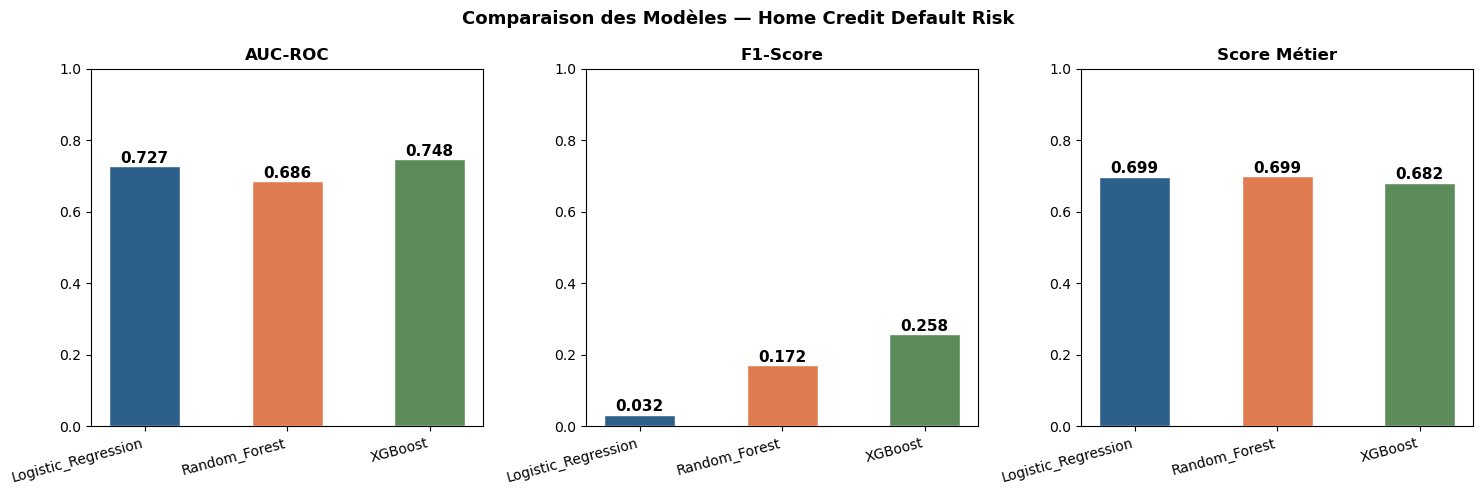

In [16]:
# Visualisation — graphique de comparaison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metriques = ['AUC-ROC', 'F1-Score', 'Score Métier']
cols_data = ['auc', 'f1', 'score_metier']
noms = [r['nom'] for r in [res_lr, res_rf, res_xgb]]

for i, (metrique, col) in enumerate(zip(metriques, cols_data)):
    valeurs = [r[col] for r in [res_lr, res_rf, res_xgb]]
    bars = axes[i].bar(noms, valeurs,
                       color=[COLOR_NEG, COLOR_POS, '#5B8C5A'],
                       edgecolor='white', width=0.5)
    axes[i].set_title(metrique, fontweight='bold', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(noms, rotation=15, ha='right')
    for bar, val in zip(bars, valeurs):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     val + 0.01, f'{val:.3f}',
                     ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Comparaison des Modèles — Home Credit Default Risk',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

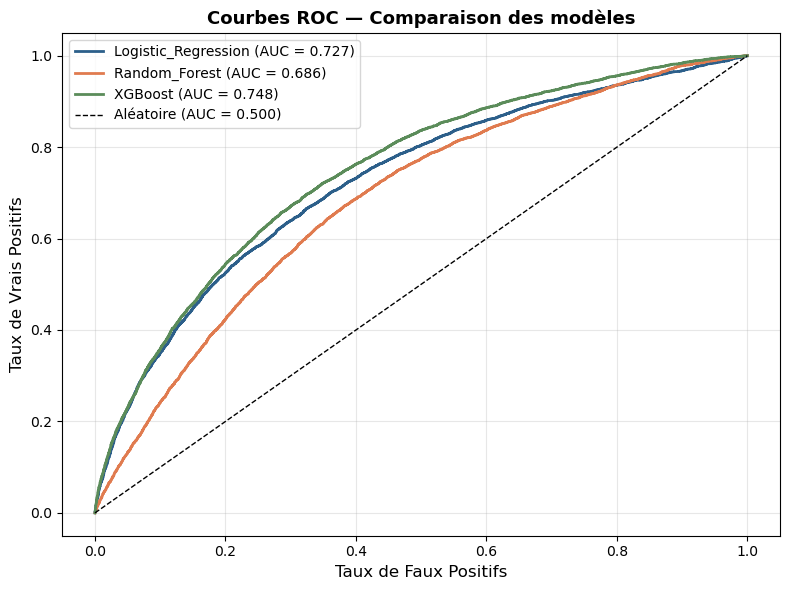

In [17]:
# Courbes ROC des 3 modèles
fig, ax = plt.subplots(figsize=(8, 6))

couleurs = [COLOR_NEG, COLOR_POS, '#5B8C5A']
for res, couleur in zip([res_lr, res_rf, res_xgb], couleurs):
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    ax.plot(fpr, tpr, color=couleur, linewidth=2,
            label=f'{res["nom"]} (AUC = {res["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.500)')
ax.set_xlabel('Taux de Faux Positifs', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/fig_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Étape 7 — Analyse SHAP (Explainability)

**C'est quoi SHAP ?**  
SHAP explique POURQUOI le modèle a pris une décision.  
Pour chaque prédiction, SHAP dit : *"Cette feature a contribué +0.3 au risque, celle-là -0.1..."*

C'est crucial pour la soutenance — le jury va te demander d'expliquer ton modèle.

In [18]:
print('Calcul des valeurs SHAP (peut prendre 1-2 minutes)...')

# On utilise XGBoost car SHAP est optimisé pour ce modèle
explainer = shap.TreeExplainer(res_xgb['modele'])

# On calcule les SHAP sur un échantillon de 1000 clients (pour la rapidité)
X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print('✅ Valeurs SHAP calculées')

Calcul des valeurs SHAP (peut prendre 1-2 minutes)...
✅ Valeurs SHAP calculées


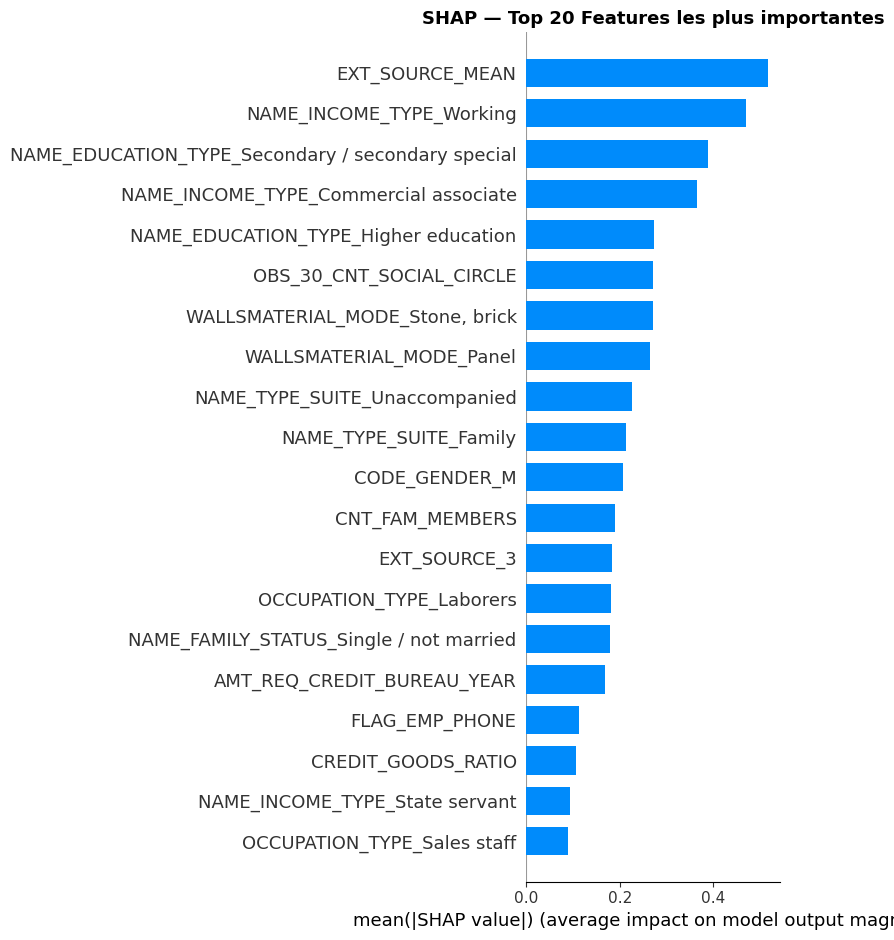


✅ Graphique SHAP sauvegardé

Comment lire ce graphique :
  → Plus la barre est longue, plus la feature influence les décisions du modèle
  → EXT_SOURCE_MEAN devrait être en tête car très corrélé avec TARGET


In [19]:
# Graphique SHAP — Top 20 features les plus importantes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP — Top 20 Features les plus importantes', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/fig_shap_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n✅ Graphique SHAP sauvegardé')
print('\nComment lire ce graphique :')
print('  → Plus la barre est longue, plus la feature influence les décisions du modèle')
print('  → EXT_SOURCE_MEAN devrait être en tête car très corrélé avec TARGET')

---
## Étape 8 — Visualiser MLflow

Pour voir tous les résultats dans l'interface MLflow :

1. Ouvre un terminal Anaconda
2. Va dans ton dossier projet :
   ```
   cd C:\Users\Frank\Desktop\home-credit-MLOPS
   ```
3. Lance MLflow :
   ```
   mlflow ui
   ```
4. Ouvre ton navigateur et va sur : **http://localhost:5000**

Tu verras les 3 modèles avec toutes leurs métriques.

In [20]:
print('=' * 60)
print('RÉCAPITULATIF MODÉLISATION')
print('=' * 60)
print(df_final[['Modèle','Seuil Optimal','AUC-ROC','F1-Score','Score Métier','Coût Total']].to_string(index=False))
print('=' * 60)
print(f'\n🏆 Meilleur modèle : XGBoost (seuil = 0.75)')
print(f'\n📁 Modèles sauvegardés dans : ../models/')
print(f'📊 Graphiques dans : ../data/processed/')
print(f'📈 MLflow : lancer "mlflow ui --backend-store-uri sqlite:///mlflow.db"')
print(f'\n🎯 Prochaine étape : 04_API_FastAPI')
print('   → On va créer une API pour utiliser le modèle')

RÉCAPITULATIF MODÉLISATION
             Modèle  Seuil Optimal  AUC-ROC  F1-Score  Score Métier  Coût Total
            XGBoost           0.75   0.7476    0.2788        0.7348       21581
Logistic_Regression           0.20   0.7271    0.2781        0.7338       21659
      Random_Forest           0.55   0.6861    0.1321        0.7007       24356

🏆 Meilleur modèle : XGBoost (seuil = 0.75)

📁 Modèles sauvegardés dans : ../models/
📊 Graphiques dans : ../data/processed/
📈 MLflow : lancer "mlflow ui --backend-store-uri sqlite:///mlflow.db"

🎯 Prochaine étape : 04_API_FastAPI
   → On va créer une API pour utiliser le modèle


In [22]:
# Log complet dans MLflow avec seuils optimisés
import mlflow

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('home-credit-scoring')

modeles_info = [
    {
        'nom'    : 'Logistic_Regression',
        'auc'    : 0.7271,
        'f1'     : 0.2781,
        'metier' : 0.7338,
        'cout'   : 21659,
        'fn'     : 3456,
        'fp'     : 4379,
        'params' : {'max_iter': 1000, 'class_weight': 'balanced', 'seuil_optimal': 0.20}
    },
    {
        'nom'    : 'Random_Forest',
        'auc'    : 0.6861,
        'f1'     : 0.1321,
        'metier' : 0.7007,
        'cout'   : 24356,
        'fn'     : 4473,
        'fp'     : 1991,
        'params' : {'n_estimators': 200, 'max_depth': 10, 'class_weight': 'balanced', 'seuil_optimal': 0.55}
    },
    {
        'nom'    : 'XGBoost',
        'auc'    : 0.7476,
        'f1'     : 0.2788,
        'metier' : 0.7348,
        'cout'   : 21581,
        'fn'     : 3498,
        'fp'     : 4091,
        'params' : {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'seuil_optimal': 0.75}
    }
]

# Supprimer les anciens runs
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name('home-credit-scoring')
if exp:
    old_runs = client.search_runs(exp.experiment_id)
    for r in old_runs:
        client.delete_run(r.info.run_id)
    print(f'🗑️ {len(old_runs)} anciens runs supprimés')

# Logger les 3 modèles
for info in modeles_info:
    with mlflow.start_run(run_name=info['nom']):
        mlflow.log_params(info['params'])
        mlflow.log_metric('AUC_ROC',       info['auc'])
        mlflow.log_metric('F1_Score',      info['f1'])
        mlflow.log_metric('Score_Metier',  info['metier'])
        mlflow.log_metric('Cout_Total',    info['cout'])
        mlflow.log_metric('Faux_Negatifs', info['fn'])
        mlflow.log_metric('Faux_Positifs', info['fp'])
        print(f'✅ {info["nom"]} loggué')

print('✅ MLflow mis à jour')
print('Lance : mlflow ui --backend-store-uri sqlite:///mlflow.db')

🗑️ 6 anciens runs supprimés
✅ Logistic_Regression loggué
✅ Random_Forest loggué
✅ XGBoost loggué
✅ MLflow mis à jour
Lance : mlflow ui --backend-store-uri sqlite:///mlflow.db


In [23]:
import os
print(os.path.abspath('mlflow.db'))

C:\Users\Frank\Desktop\home-credit-MLOPS\notebooks\mlflow.db


In [24]:
gitignore_content = """data/raw/
data/processed/
models/
mlruns/
notebooks/mlflow.db
__pycache__/
*.pkl
*.csv
.ipynb_checkpoints/
"""

with open(r'C:\Users\Frank\Desktop\home-credit-MLOPS\.gitignore', 'w') as f:
    f.write(gitignore_content)

print('✅ .gitignore créé')

✅ .gitignore créé


In [26]:
import os

# Créer le dossier
os.makedirs(r'C:\Users\Frank\Desktop\home-credit-MLOPS\.github\workflows', exist_ok=True)

contenu = """name: CI - Home Credit MLOps

on:
  push:
    branches: [ main ]
  pull_request:
    branches: [ main ]

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Recuperer le code
        uses: actions/checkout@v3

      - name: Installer Python
        uses: actions/setup-python@v4
        with:
          python-version: '3.10'

      - name: Installer les dependances
        run: |
          pip install fastapi uvicorn pydantic xgboost scikit-learn joblib numpy pandas

      - name: Verifier schemas
        run: |
          cd api
          python -c "from schemas import ClientData, PredictionResponse; print('Schemas OK')"
"""

with open(r'C:\Users\Frank\Desktop\home-credit-MLOPS\.github\workflows\ci.yml', 'w', encoding='utf-8') as f:
    f.write(contenu)

print('Fichier CI/CD cree')

Fichier CI/CD cree


In [28]:
import subprocess
subprocess.run(['pip', 'install', 'evidently', '--break-system-packages', '-q'])
print('OK')

OK
